# Emulation of Waves
## Weather Typing + Probabilistic - Copula Model
## Predictor- Load Weather Types

In [1]:
from bluemath_tk.core.io import load_model

daily_xwt = load_model("outputs/dwt_model_alexandria.pkl")
dwts_to_fit = (
    daily_xwt.steps.get("pca")
    .pcs.kma_bmus.to_dataset(name="bmus")
    .sel(time=slice("1979", "2018"))
)
dwts_to_fit["cenEOFs"] = (
    ("n_clusters", "n_features"),
    daily_xwt.steps.get("kma").kma.cluster_centers_,
)
dwts_to_fit

<xarray.Dataset> Size: 177kB
Dimensions:  (time: 14610, n_clusters: 36, n_features: 12)
Coordinates:
  * time     (time) datetime64[ns] 117kB 1979-01-01 1979-01-02 ... 2018-12-31
Dimensions without coordinates: n_clusters, n_features
Data variables:
    bmus     (time) int32 58kB 11 11 5 33 33 31 31 32 ... 27 26 32 31 34 34 22
    cenEOFs  (n_clusters, n_features) float32 2kB -1.513 5.397 ... -0.00174

## Predictand- Load regional/local wave data
### significant wave height, peak period, mean wave direction

In [2]:
import xarray as xr

predictand = (
    xr.open_dataset("inputs/daily_predictand_1979_2018.nc")
    .sel(time=dwts_to_fit.time, method="nearest", tolerance="1H")
    .rename({"swh": "bulk_Hs", "pp1d": "bulk_Tp", "mwd": "bulk_Dir"}) # , "ss": "bulk_ss"
)
predictand["EF"] = predictand.bulk_Hs**2 + predictand.bulk_Tp
predictand["bmus"] = (("time"), dwts_to_fit["bmus"].values)
predictand

<xarray.Dataset> Size: 760kB
Dimensions:   (time: 14610)
Coordinates:
  * time      (time) datetime64[ns] 117kB 1979-01-01 1979-01-02 ... 2018-12-31
Data variables:
    bulk_Hs   (time) float64 117kB 0.9979 1.402 2.481 ... 1.188 0.9691 0.9028
    bulk_Tp   (time) float64 117kB ...
    bulk_Dir  (time) float64 117kB ...
    ss        (time) float64 117kB ...
    EF        (time) float64 117kB 6.84 8.322 14.03 29.84 ... 8.365 6.75 6.592
    bmus      (time) int32 58kB 11 11 5 33 33 31 31 32 ... 27 26 32 31 34 34 22

## Predictand to Predictor- Model
## Probabilistic - Copula Model

In [3]:
from bluemath_tk.teslakit.climate_emulator import Climate_Emulator

ce = Climate_Emulator("outputs/emulator")

config = {
    "waves_families": ["bulk"],
    "distribution": [("ss", "Empirical")],
    "do_chromosomes": False,
    "extra_variables": ["ss"],
}
ce.FitExtremes(KMA=dwts_to_fit, WVS=predictand, config=config, proxy="EF")

Waves Families: ['bulk']
Extra Variables: ['ss']
GEV distribution: ['bulk_Hs', 'bulk_Tp']
Empirical distribution: ['bulk_Dir', 'ss']
Weibull distribution: []
Do chromosomes combinations: False
Max. Storms PROXY: EF


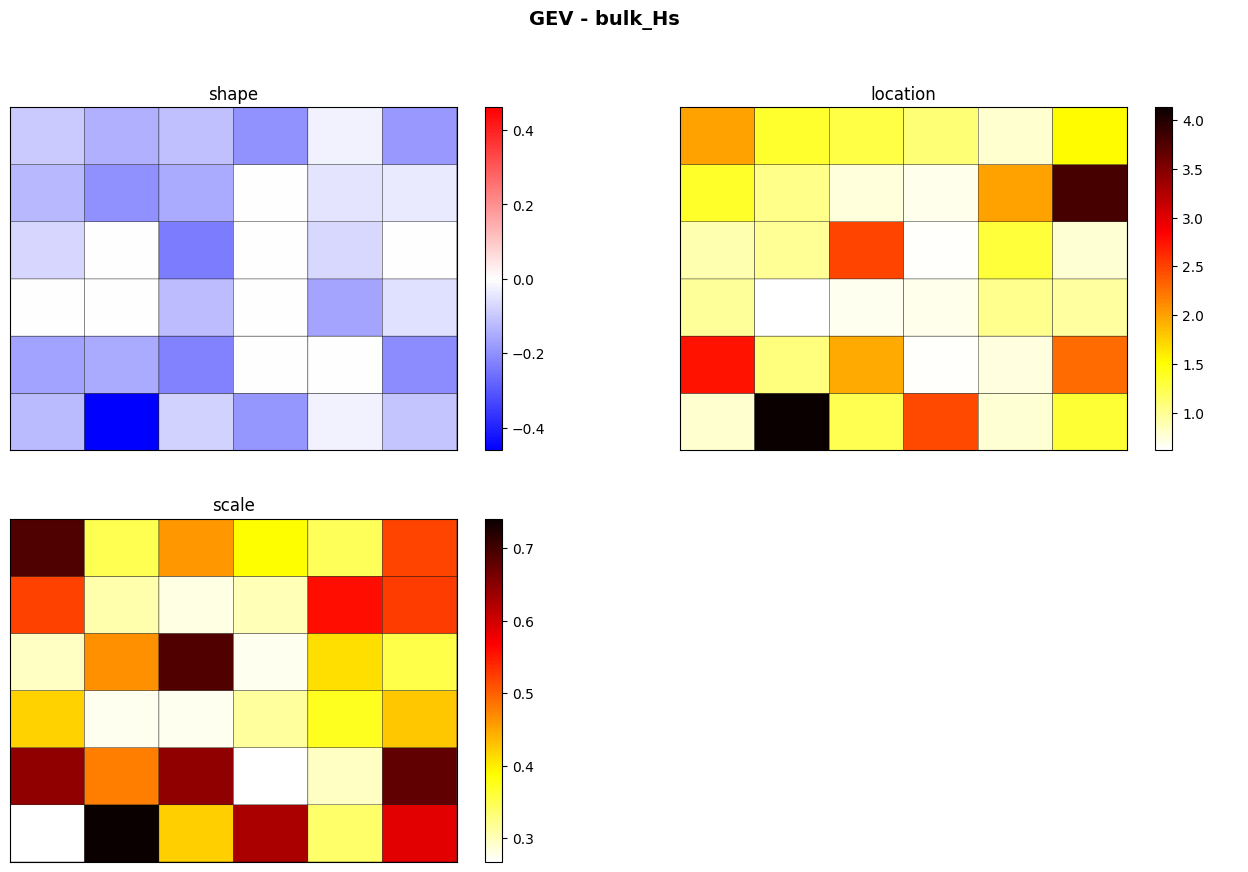

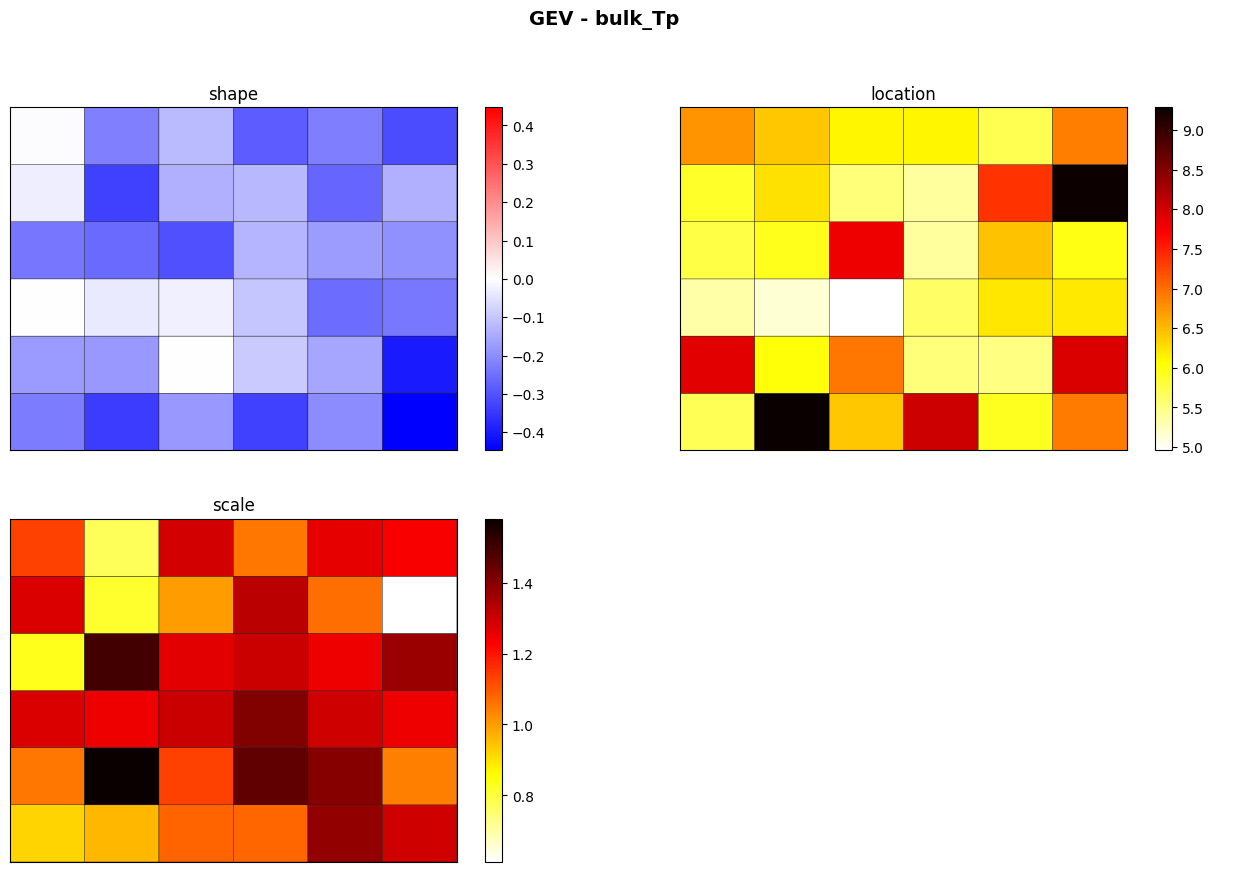

In [4]:
# Fit report figures

ce.Report_Fit(vns_GEV=["Hs", "Tp"], plot_chrom=False, plot_sigma=False);

## Climate Emulator
### Emulation of Weather Types + Emulation of Waves

In [5]:
# Load simulated DWTs

simulated_dwts = xr.open_dataset("outputs/xds_output.nc")
simulated_dwts

<xarray.Dataset> Size: 1MB
Dimensions:      (time: 36891, n_sim: 5)
Coordinates:
  * time         (time) datetime64[ns] 295kB 1999-01-01 ... 2100-01-01
Dimensions without coordinates: n_sim
Data variables:
    evbmus_sims  (time, n_sim) int32 738kB ...
    ofbmus_sims  (time, n_sim) bool 184kB ...

In [6]:
simulated_waves = ce.Simulate_Waves(simulated_dwts.isel(n_sim=0), 1)
simulated_waves

C.E: Sim. Waves: 100%|██████████| 24285/24285 [04:03<00:00, 99.83it/s] 


<xarray.Dataset> Size: 1MB
Dimensions:   (n_sim: 1, time: 24285)
Coordinates:
  * time      (time) datetime64[ns] 194kB 1999-01-01 1999-01-02 ... 2100-01-01
Dimensions without coordinates: n_sim
Data variables:
    DWT       (n_sim, time) int32 97kB 11 5 33 23 30 22 28 ... 31 30 33 29 33 34
    bulk_Hs   (n_sim, time) float64 194kB 1.505 4.086 0.8512 ... 1.135 0.5996
    bulk_Tp   (n_sim, time) float64 194kB 4.909 9.581 6.07 ... 5.838 6.694 6.038
    bulk_Dir  (n_sim, time) float64 194kB 159.2 300.6 306.0 ... 144.0 168.5
    ss        (n_sim, time) float64 194kB 0.003965 0.1109 ... 0.08769 0.06119

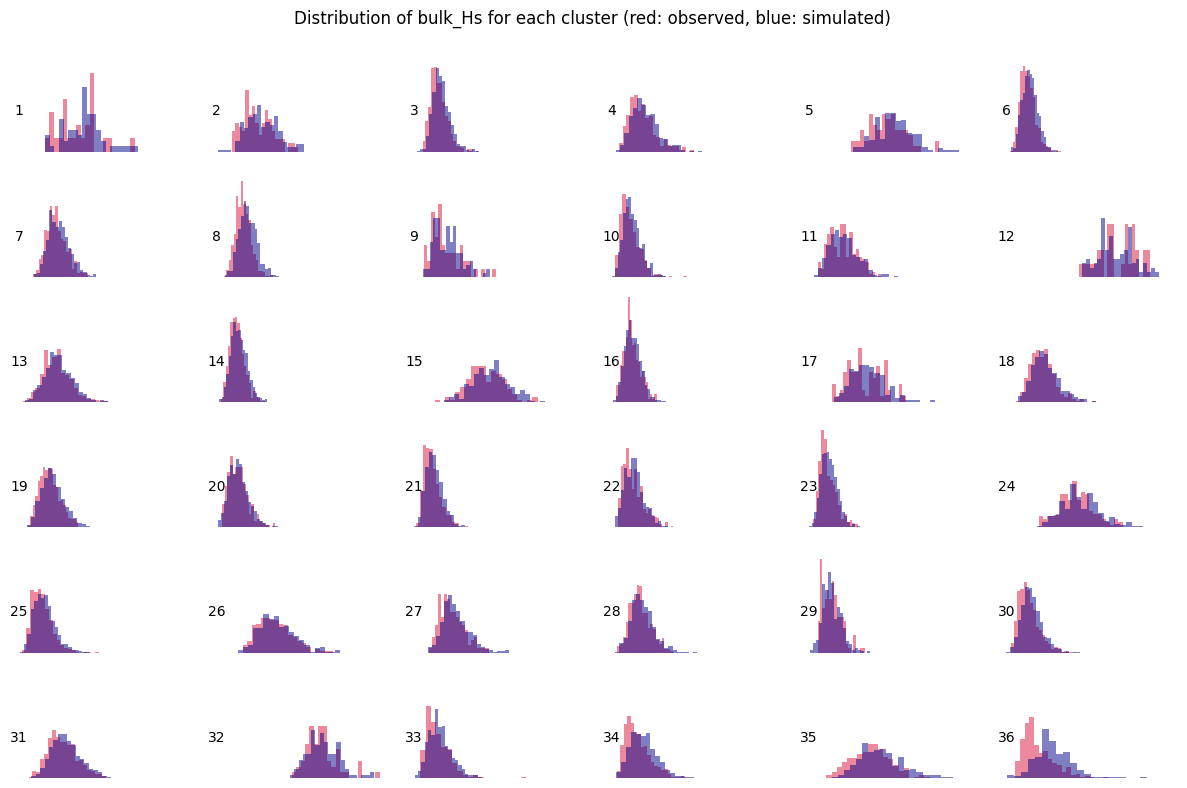

In [7]:
import matplotlib.pyplot as plt

var_to_plot = "bulk_Hs"

fig, axes = plt.subplots(6, 6, figsize=(12, 8), sharex=True, sharey=True)
for cluster, ax in enumerate(axes.flatten()):
    predictand.isel(time=predictand.groupby("bmus").groups.get(cluster + 1))[
        var_to_plot
    ].plot.hist(ax=ax, density=True, alpha=0.5, bins=20, color="crimson")
    simulated_waves.isel(time=simulated_waves.groupby("DWT").groups.get(cluster + 1))[
        var_to_plot
    ].plot.hist(ax=ax, density=True, alpha=0.5, bins=20, color="darkblue")
    ax.axis("off")
    ax.text(0, 0.7, f"{cluster + 1}", fontsize=10, ha="center", va="center")
    fig.suptitle(
        f"Distribution of {var_to_plot} for each cluster (red: observed, blue: simulated)",
        fontsize=12,
        ha="center",
        va="top",
    )
plt.subplots_adjust(top=0.9)
plt.tight_layout()

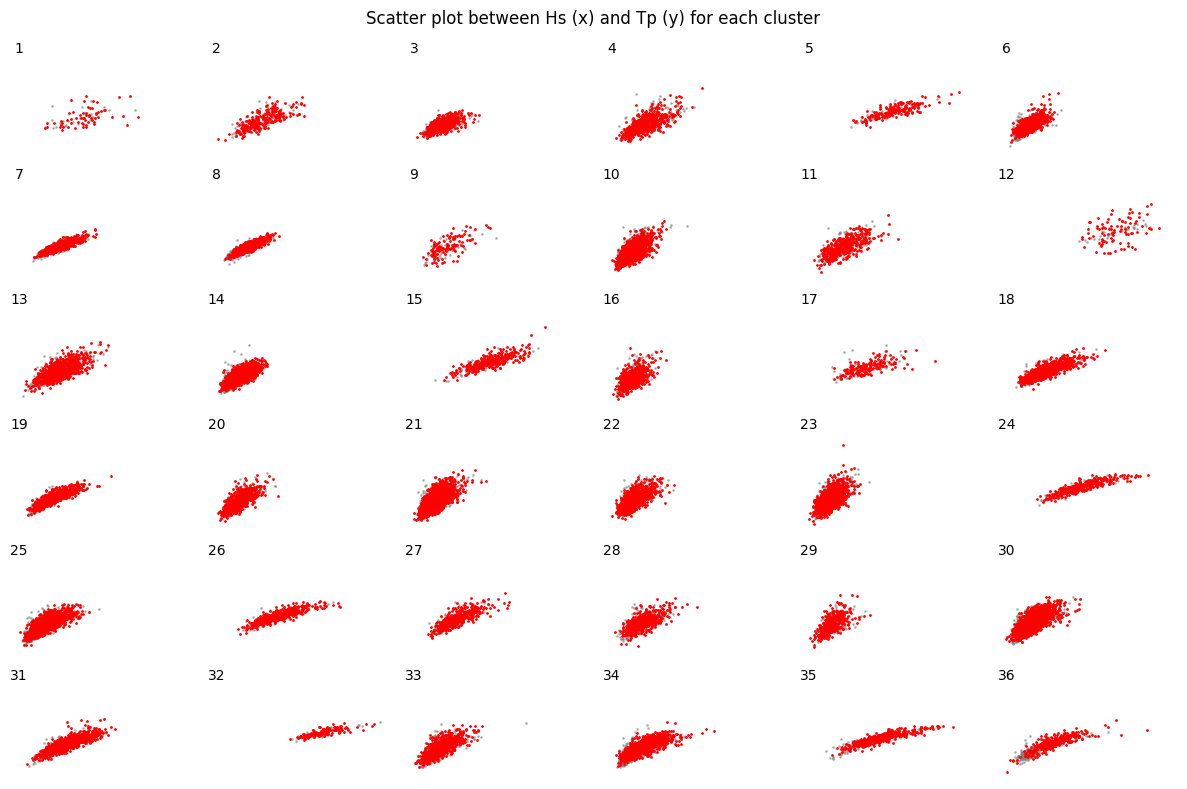

In [8]:
import matplotlib.colors as mcolors
import numpy as np

cmap = plt.cm.get_cmap("bwr")
norm = mcolors.Normalize(vmin=-0.5, vmax=0.5)
# Get correlation values
corr_values = np.array([ce.sigma[cluster][0]["corr"][0, 1] for cluster in range(1, 37)])
# Get colors for the correlation values
corr_values_colors = [cmap(norm(value)) for value in corr_values]
# Plot the correlation values
fig, axes = plt.subplots(6, 6, figsize=(12, 8), sharex=True, sharey=True)
for cluster, ax in enumerate(axes.flatten()):
    predictand.isel(
        time=predictand.groupby("bmus").groups.get(cluster + 1)
    ).plot.scatter(ax=ax, x="bulk_Hs", y="bulk_Tp", s=1, color="grey", alpha=0.5)
    simulated_waves.isel(
        time=simulated_waves.groupby("DWT").groups.get(cluster + 1)
    ).plot.scatter(
        ax=ax, x="bulk_Hs", y="bulk_Tp", s=1, color=corr_values_colors[cluster]
    )
    ax.axis("off")
    ax.text(0, 20, f"{cluster + 1}", fontsize=10, ha="center", va="center")
fig.suptitle(
    "Scatter plot between Hs (x) and Tp (y) for each cluster",
    fontsize=12,
    ha="center",
    va="top",
)
plt.subplots_adjust(top=0.9)
plt.tight_layout()